### import libraries

In [2]:
import sys
sys.path.append('C:/Users/hgs-a/Dropbox/hgs/programme/hgs_xrr_package')
from foofit_package import *
import foofit_package

### necessary to plot data
%matplotlib notebook

import glob
import scipy
from scipy.ndimage.filters import gaussian_filter1d
import cycler
import re

np.seterr(divide='ignore', invalid='ignore')

{'divide': 'ignore', 'over': 'warn', 'under': 'ignore', 'invalid': 'ignore'}

In [3]:
def patterson(dataFile, save=True,
           maxZ = 2000,
           qMin = 0.03, qMax = 0.2,
           rrfNorm = True, zCutOff = 70,
           rho_sub = 0.71, rho_pre = 0.,
           meanSub = False, windowFunc = False, padding = False,
           norm = True,
           plot = False, logPlot = True, scale = 1,
           method = 0, modo = True, outputFile = 'foo'):
    
    data = np.loadtxt(dataFile)
    qq = data[:,0]
    ii = data[:,1]
      
    
####################################################################################### FFT    
    if method == 0:
        
        maxZ*=10
    
        qq_interp = np.arange(np.min(qq), np.max(qq), np.pi/maxZ)
        ii_interp = np.interp(qq_interp, qq, ii)
        qq = qq_interp
        ii = ii_interp
        qq2 = qq[(qq > qMin) & (qq < qMax)]; ii2 = ii[(qq > qMin) & (qq < qMax)]
        qq = qq2; ii = ii2
        dq = np.diff(qq)

        delta = rho_sub - rho_pre
        rf = abs( ( qq - sqrt(qq**2 - (0.0375*sqrt(delta))**2 ) ) / ( qq + sqrt(qq**2 - (0.0375*sqrt(delta))**2 ) ) ) **2 
        if rrfNorm:
            rrf = ii/rf; np.place(rrf, np.isnan(rrf), 1)
        else:
            rrf = ii*qq**4; np.place(rrf, np.isnan(rrf), 1)

        if meanSub:
            rrf -= np.mean(rrf)

        if windowFunc:
            w = bartlett(len(rrf))
        else:
            w = np.ones(len(rrf))

        rrf_w = rrf * w
        
        if padding:
            ps = pSpectrum_padded(rrf_w)
            freq = np.linspace(0, np.pi/(qq[3]-qq[2]), len(ps))
        else:
            ps = pSpectrum_nonPadded(rrf_w)
            freq = np.linspace(0, np.pi/(qq[3]-qq[2]), len(ps))

        ps_cut = ps[:int(len(ps)*0.1)]
        freq_cut = freq[:int(len(freq)*0.1)]
        
        distance = freq_cut
        patterson = ps_cut
        
    
####################################################################################### Manual        
    if method == 1:
        
        qq2 = qq[(qq > qMin) & (qq < qMax)]; ii2 = ii[(qq > qMin) & (qq < qMax)]
        qq = qq2; ii = ii2

        dq = np.diff(qq)

        delta = rho_sub - rho_pre
        rf = abs( ( qq - sqrt(qq**2 - (0.0375*sqrt(delta))**2 ) ) / ( qq + sqrt(qq**2 - (0.0375*sqrt(delta))**2 ) ) ) **2 
        if rrfNorm:
            rrf = ii/rf; np.place(rrf, np.isnan(rrf), 1)
        else:
            rrf = ii*qq**4; np.place(rrf, np.isnan(rrf), 1)

        if meanSub:
            rrf -= np.mean(rrf)

        if windowFunc:
            w = bartlett(len(rrf))
        else:
            w = np.ones(len(rrf))

        rrf_w = rrf * w
        
        ### How many data points in patterson function
        ### This is also the z-range
        sample = maxZ
        ### Sampling rate
        rate = 1
        ### Make zz array (z-axis)
        zz = np.arange(0,sample,rate)
        ### Make complex patterson-function array
        patt=np.zeros(len(zz), dtype=np.complex64)

        ### Perform manual Fourier Transform
        for ii in zz:
            for jj, mm, yy in zip(qq,rrf_w,dq):
                patt[ii] += mm * np.exp (1j* ii * jj ) * yy 

        if modo:
            patt_final = np.abs(patt)**2
        else:
            patt_final = (patt)
#             print(patt)
        
        distance = zz
        patterson = patt_final

    if norm:
        patterson /= np.amax(patterson)
        
    patterson[distance < zCutOff] = np.nan
    
    if plot:
        plt.plot(distance,patterson * scale, label=dataFile)
        
    if logPlot:
        plt.semilogy(distance,patterson * scale, label=dataFile)
#         plt.semilogy(distance,np.abs(patterson)**2 * scale, label=dataFile) 
        
    plt.legend()    
        
    if save:
        if method == 0:
            np.savetxt("%s.fft"%(outputFile), np.column_stack((distance,patterson))) 
            print('done')
        if method == 1:
            np.savetxt("%s.ftMan"%(outputFile), np.column_stack((distance,patterson)))
            print('%s is done'%dataFile)
            
def pSpectrum_nonPadded(inputData):
    
    numDataPoints = len(inputData)
    pSpect = np.abs(np.fft.fft(inputData))**2
    pSpect = pSpect[0:int(np.round(numDataPoints/2))]
    
    return pSpect

def pSpectrum_padded(inputData):
    
    numDataPoints = len(inputData)
    
    paddedData = np.zeros(2 * numDataPoints, dtype=float32)
    paddedData[0:numDataPoints] = inputData
    
    pSpect = np.abs(np.fft.fft(paddedData))**2
    pSpect = pSpect[0:numDataPoints]
    
    return pSpect

def plotXrr(dataFile, rho_sub = 0.71, rho_pre = 0., rffPlot = True, scale = 1):
    data = np.loadtxt(dataFile)
    qq = data[:,0]
    ii = data[:,1]
    delta = rho_sub - rho_pre
    rf = abs( ( qq - sqrt(qq**2 - (0.0375*sqrt(delta))**2 ) ) / ( qq + sqrt(qq**2 - (0.0375*sqrt(delta))**2 ) ) ) **2 
    
    if rffPlot:
        plt.semilogy(qq,ii/rf * scale, label=dataFile)
    else:
        plt.semilogy(qq,ii * scale, label=dataFile)
        
    plt.legend()
    
def atof(text):
    try:
        retval = float(text)
    except ValueError:
        retval = text
    return retval

def natural_keys(text):
    '''
    alist.sort(key=natural_keys) sorts in human order
    http://nedbatchelder.com/blog/200712/human_sorting.html
    (See Toothy's implementation in the comments)
    float regex comes from https://stackoverflow.com/a/12643073/190597
    '''
    return [ atof(c) for c in re.split(r'[+-]?([0-9]+(?:[.][0-9]*)?|[.][0-9]+)', text) ]

In [4]:
def get_all_ft(qMAX = 0.6, qMin = 0.15):
    fileList = sorted(glob.glob("*xrr"), key=natural_keys)
    for fileName in fileList:
        patterson(fileName, scale=1., qMax=qMAX, qMin = qMIN,
              maxZ=500, zCutOff=0, method=1, norm = False, plot=False, logPlot = False,
              outputFile='%s_%s_%s'%(fileName, qMIN,qMAX))

In [5]:
def plot_all(rho_sub = 0.71, rho_pre = 0.,
            xmin1 = 0, xmax1 = 0.7, 
            xmin2 = 0, xmax2 = 350, ymin2 = 0, ymax2 = 4e-4,
            save = True, plotLegend = True, doScale = True, norm=True,
            outputFile = 'foo'):
    fileList_xr = sorted(glob.glob("*xrr"), key=natural_keys)
    fileList_ft = sorted(glob.glob("*ftMan"), key=natural_keys)
    color = cm.gnuplot(np.linspace(0, 1, len(fileList_xr)))
    mpl.rcParams['axes.prop_cycle'] = cycler.cycler('color', color)
    
    plt.rc("font", size=14); plt.rc('legend',**{'fontsize':14}); plt.rcParams['font.family']='M+ 2c'
    plt.rcParams['xtick.direction'] = 'in'; plt.rcParams['ytick.direction'] = 'in'; rcParams['figure.figsize'] = 9.3,6
    fig=figure()
       
    gs = gridspec.GridSpec(1,2)
    gs.update(wspace=0.03)
    ax1 = plt.subplot(gs[0, 0])
    ax2 = plt.subplot(gs[0, 1])
    
        ############################## Make plot for reflectivity
    ax1.set_xlabel("q$_\mathregular{z}$ (\u00c5$\mathregular{^{-1}}$)")
    ax1.set_ylabel("R/R$_\mathregular{F}$")
    ax1.yaxis.set_ticks_position('both'); ax1.xaxis.set_ticks_position('both')
    
    ax2.set_xlabel("d (\u00c5)")
    ax2.set_ylabel("FT(R/R$_\mathregular{F}$)", rotation=-90)
    ax2.yaxis.labelpad = 24
    ax2.yaxis.set_ticks_position('both'); ax1.xaxis.set_ticks_position('both')
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()
    
    ax1.set_xlim(xmin1, xmax1)
    ax2.set_xlim(xmin2, xmax2)
    ax2.set_ylim(ymin2, ymax2)

    nn = 1
    for fileName in fileList_xr:
        data = np.loadtxt(fileName)
        qq = data[:,0]; ii = data[:,1]
        delta = rho_sub - rho_pre
        rf = abs( ( qq - sqrt(qq**2 - (0.0375*sqrt(delta))**2 ) ) / ( qq + sqrt(qq**2 - (0.0375*sqrt(delta))**2 ) ) ) **2 
        ax1.semilogy(qq,ii/rf * nn, label=fileName, linewidth = 1)
        nn*=100
        
    mm = 0   
    
    if norm:
        for fileName in fileList_ft:
            data = np.loadtxt(fileName)
            rr = data[:,0]; pp = data[:,1]
            if doScale:
                ax2.plot(rr,pp/np.max(pp) + mm, label=fileName, linewidth = 1)
            else:
                ax2.plot(rr,pp/np.max(pp), label=fileName, linewidth = 1)
            if mm == 0:
                scale = np.max(pp/np.max(pp)/10)
            mm+=scale
            if plotLegend:
                ax2.legend(fontsize = 8)
                
    else:
        for fileName in fileList_ft:
            data = np.loadtxt(fileName)
            rr = data[:,0]; pp = data[:,1]
            if doScale:
                ax2.plot(rr,pp + mm, label=fileName, linewidth = 1)
            else:
                ax2.plot(rr,pp, label=fileName, linewidth = 1)
            if mm == 0:
                scale = np.max(pp/10)
            mm+=scale
            if plotLegend:
                ax2.legend(fontsize = 8)
        
    ax1.set_title(fileList_xr[0], fontsize=12)
    ax2.set_title(fileList_xr[-1], fontsize=12)
    
    ax2.axvline(x=252.2, color='k', alpha = 0.3, linewidth = .7)
    
    if save:
        savefig("C:/Users/hgs-a/Dropbox/hgs/projects/other/moffitt_izo/figures/%s.png"%(outputFile),
                bbox_inches='tight', dpi=600)    
        

In [13]:
pwd

'C:\\Users\\hgs-a\\Dropbox\\hgs\\projects\\other\\moffitt_izo\\Air_ex_situ_March2019\\Air_ex_situ_March2019'

In [14]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\Air_ex_situ_March2019\Air_ex_situ_March2019

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\Air_ex_situ_March2019\Air_ex_situ_March2019


<IPython.core.display.Javascript object>


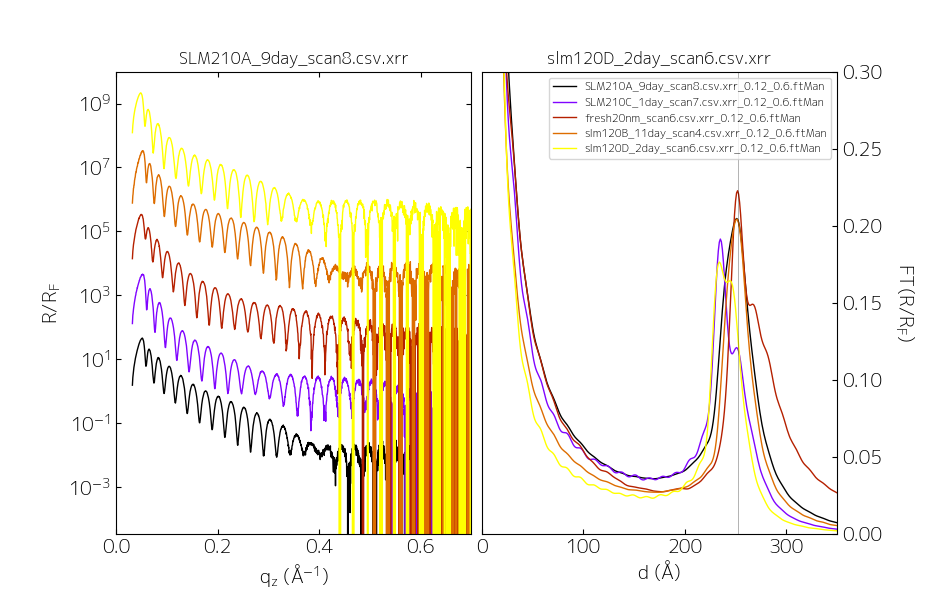

In [15]:
plot_all(outputFile = "Air_ex_situ_March2019_v2", save=True, ymax2 = .3, doScale = False, norm=True)

<IPython.core.display.Javascript object>


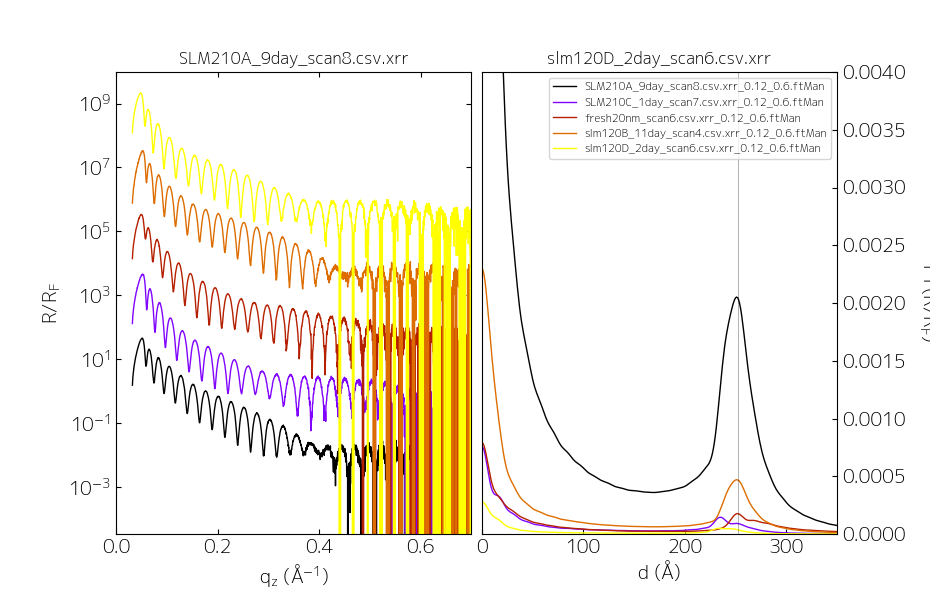

In [8]:
plot_all(outputFile = "Air_ex_situ_March2019", save=True, ymax2 = 4e-3, doScale = False, norm=False)

In [71]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\Intial_rm_temp\Intial_rm_temp

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\Intial_rm_temp\Intial_rm_temp


<IPython.core.display.Javascript object>


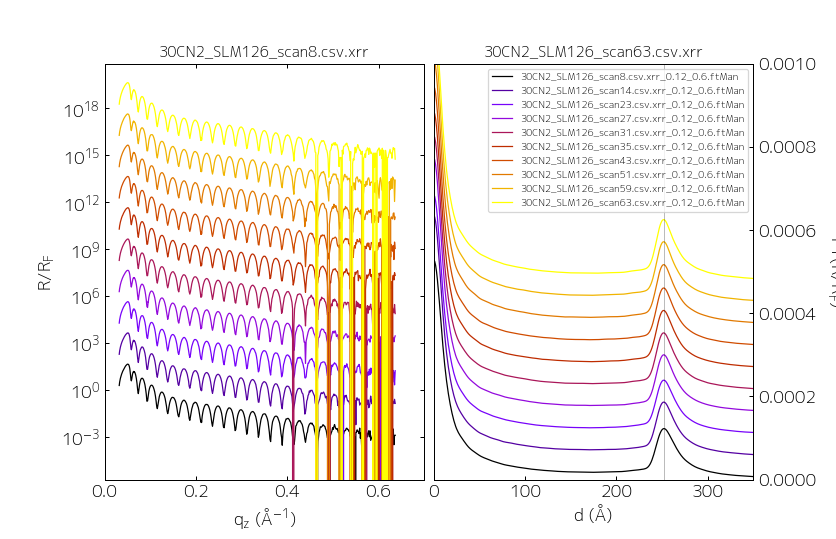

In [72]:
plot_all(outputFile = "Intial_rm_temp", save=True, ymax2 = 1e-3)

In [73]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\A_200C_N2\A_200C_N2

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\A_200C_N2\A_200C_N2


<IPython.core.display.Javascript object>


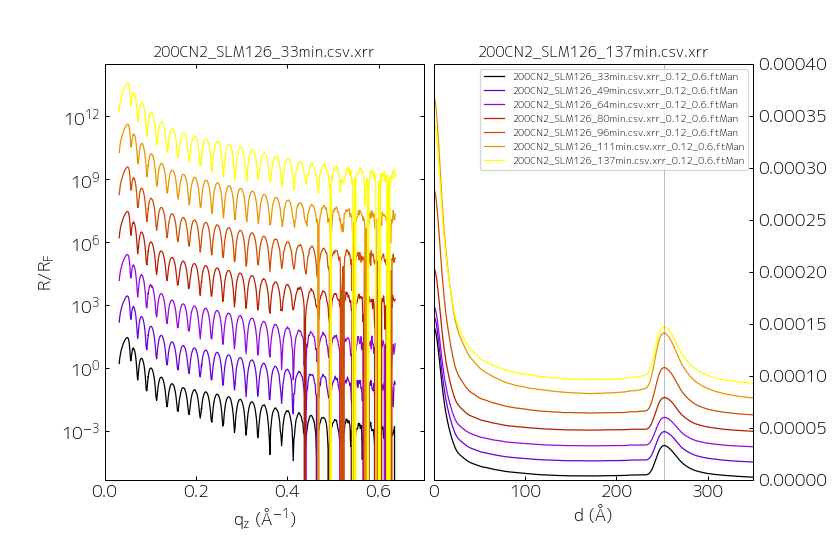

In [74]:
plot_all(outputFile = "A_200C_N2", save=True, ymax2 = 4e-4)

In [75]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\B_200C_O2\B_200C_O2

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\B_200C_O2\B_200C_O2


<IPython.core.display.Javascript object>


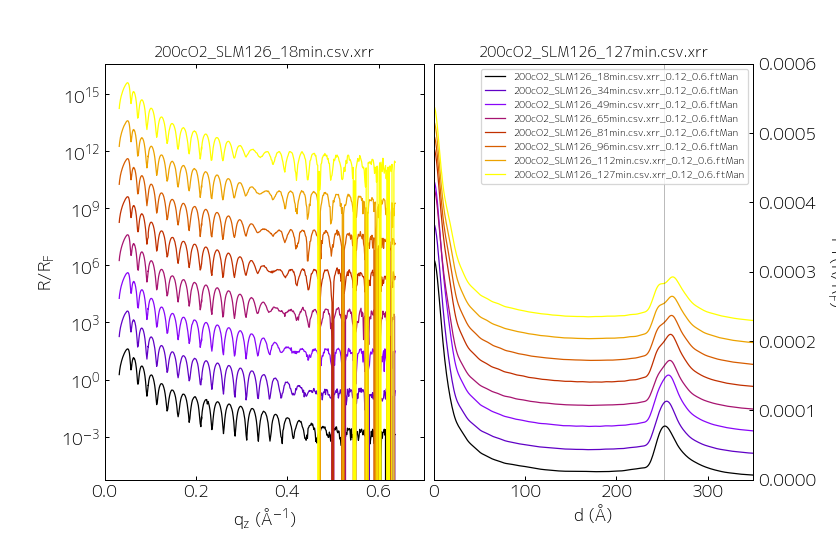

In [76]:
plot_all(outputFile = "B_200C_O2", save=True, ymax2 = 6e-4)

In [77]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\C_200CN2\C_200CN2

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\C_200CN2\C_200CN2


<IPython.core.display.Javascript object>


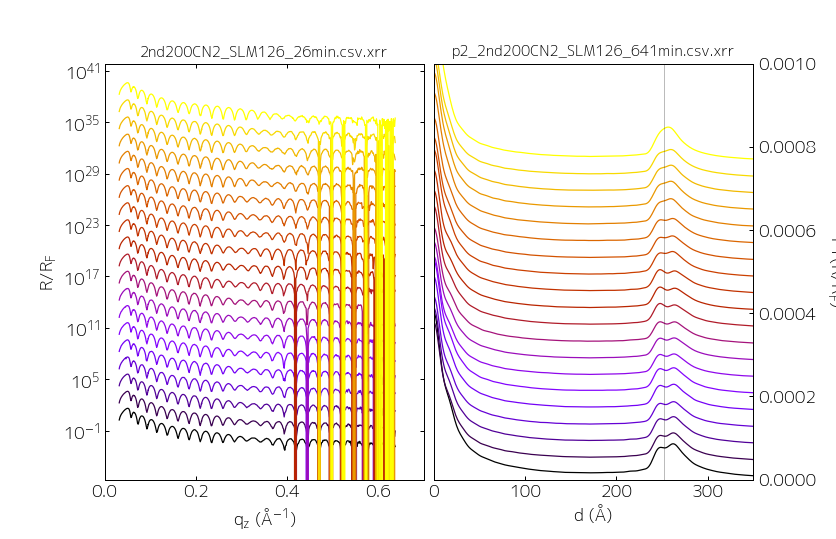

In [78]:
plot_all(outputFile = "C_200CN2", save=True, ymax2 = 1e-3, plotLegend = False)

In [79]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\D_200C_O2\D_200C_O2

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\D_200C_O2\D_200C_O2


<IPython.core.display.Javascript object>


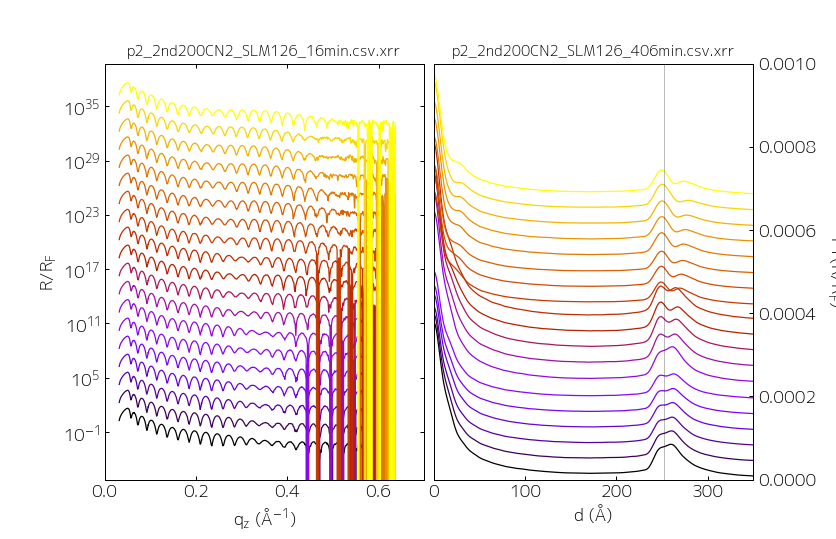

In [80]:
plot_all(outputFile = "D_200C_O2", save=True, ymax2 = 1e-3, plotLegend = False)

In [81]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\E_200C_N2\E_200C_N2

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\E_200C_N2\E_200C_N2


<IPython.core.display.Javascript object>


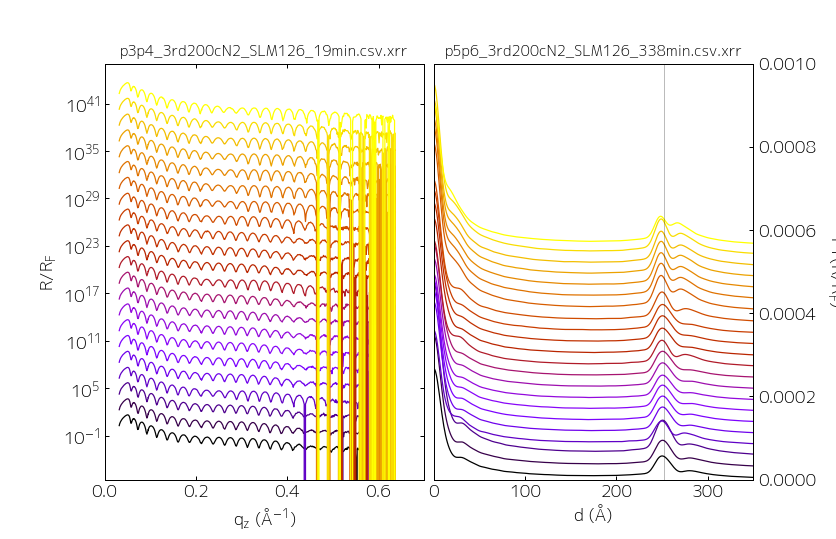

In [82]:
plot_all(outputFile = "E_200C_N2", save=True, ymax2 = 1e-3, plotLegend = False)

In [83]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\F_200C_O2\F_200C_O2

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\F_200C_O2\F_200C_O2


<IPython.core.display.Javascript object>


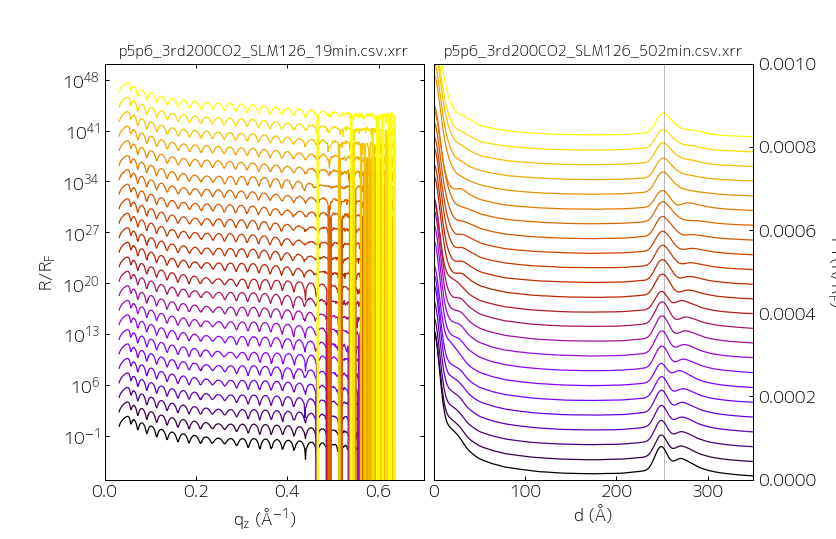

In [84]:
plot_all(outputFile = "F_200C_O2", save=True, ymax2 = 1e-3, plotLegend=False)

In [85]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\G_200C_N2\G_200C_N2

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\G_200C_N2\G_200C_N2


<IPython.core.display.Javascript object>


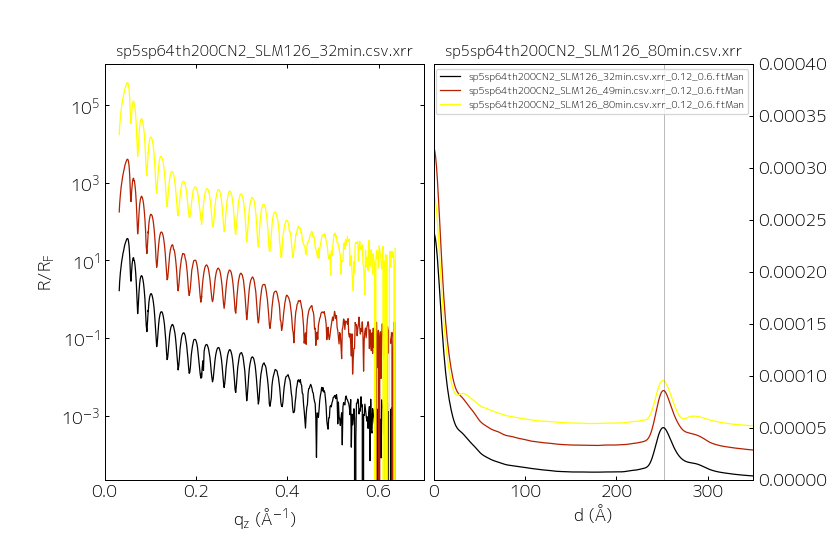

In [86]:
plot_all(outputFile = "G_200C_N2", save=True, ymax2 = 4e-4)

In [16]:
cd C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\N2_ex_situ_June2019\N2_ex_situ_June2019

C:\Users\hgs-a\Dropbox\hgs\projects\other\moffitt_izo\N2_ex_situ_June2019\N2_ex_situ_June2019


<IPython.core.display.Javascript object>


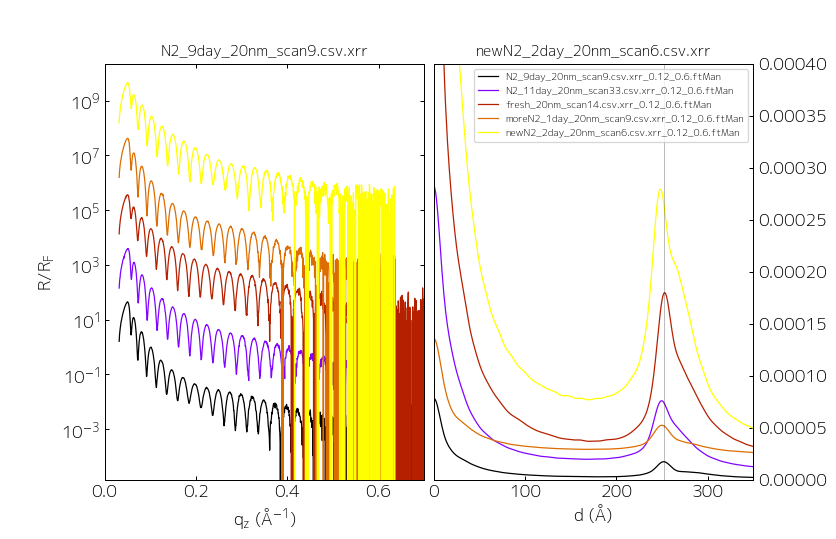

In [88]:
plot_all(outputFile = "N2_ex_situ_June2019", save=True, ymax2 = 4e-4)

<IPython.core.display.Javascript object>


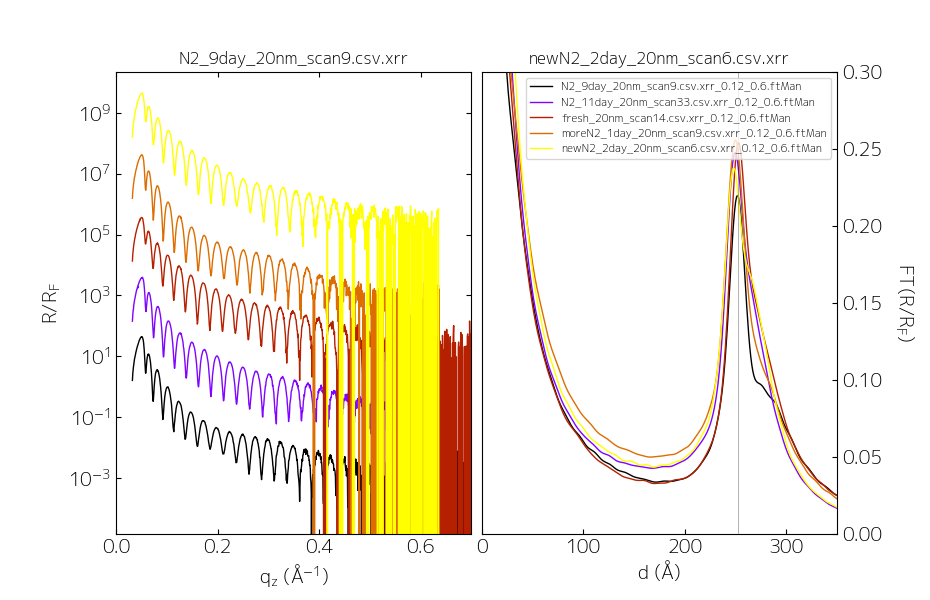

In [18]:
plot_all(outputFile = "N2_ex_situ_June2019_v2", save=True, ymax2 = .3, norm=True, doScale = False)